In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          4.84313612  0.          0.
  0.          0.         -1.50046229  0.          0.          0.
  0.          0.          0.         -8.24601537  0.         -1.56670347
  0.          0.          3.59434365  0.         -2.95706303  0.
  0.          0.          7.16864507  0.          0.         -6.51835365
  0.          0.          0.          0.          0.          0.
  0.          1.00079185  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.26738719  0.        ]


21.874303886697408

In [3]:
from sklearn.linear_model import Lasso

def lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau)

        # Generate Y_max based on true beta_star
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
    
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [4]:
def optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau):
    """
    Perform optimization using a hill-climbing algorithm under given constraints.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        C_max_wave (float): Constraint for F_t matrix eigenvalue.
        t (int): Time step or scaling factor.
        max_iterations (int): Maximum number of iterations for the algorithm.

    Returns:
        numpy array: Optimized X_max vector.
    """
    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t)) @ X_max.reshape(-1, 1))
        constant = (4 * np.sqrt(s_esti) * lamada / phi)
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


# Lasso Stochastic Bandit

In [8]:
def while_lasso_stochastic_bandit(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter

In [9]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_lasso_stochastic_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.

parameter square error:15.506371928728665
time 2: mean reward 8.478362771871542
parameter square error:14.81565518115219
time 3: mean reward 0.45059944921435324
parameter square error:15.366333335984779
time 4: mean reward 0.6502914210850204
parameter square error:15.506371928728665
time 5: mean reward -8.981044035393797
parameter square error:15.506371928728665
time 6: mean reward -0.809338057916336
parameter square error:15.506371928728665
time 7: mean reward -0.6621084897342256
parameter square error:15.506371928728665
time 8: mean reward -2.388642297283414
parameter square error:15.506371928728665
time 9: mean reward 1.9167805390469386
parameter square error:15.506371928728665
time 10: mean reward 0.21901892255855715
parameter square error:15.506371928728665
time 11: mean reward 3.299428361693799
parameter square error:15.506371928728665
time 12: mean reward 7.368663453372449
parameter square error:15.506371928728665
time 13: mean reward -1.5064357418398404
parameter square error:1

In [10]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  19.56011722   40.94492731   62.91396286 ... 6402.81363618 6404.8542391
 6406.99492121]
Cumulative Regret Std: [   4.6865076     5.87174455    7.31292426 ... 1508.05759584 1507.44328749
 1507.30730819]
L2 Error Parameter Mean: [15.52432257 15.4266679  15.49236807 15.50637193 15.50319274 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50144035 15.48110826 15.49245475 15.42858943 15.45737509
 15.45389398 15.45689041 15.458822   15.47299399 15.43647649 15.43705965
 15.43037939 15.44154004 15.44369567 15.44583716 15.44964902 15.42932178
 15.43087718 15.44611015 15.44900848 15.43533815 15.43813603 15.44649058
 15.44041481 15.42366513 15.40622542 15.40243672 15.403872   15.37154584
 15.34775386 15.3541939  15.26856555 15.26743739 15.18224017 15.11516923
 15.0454678  14.9

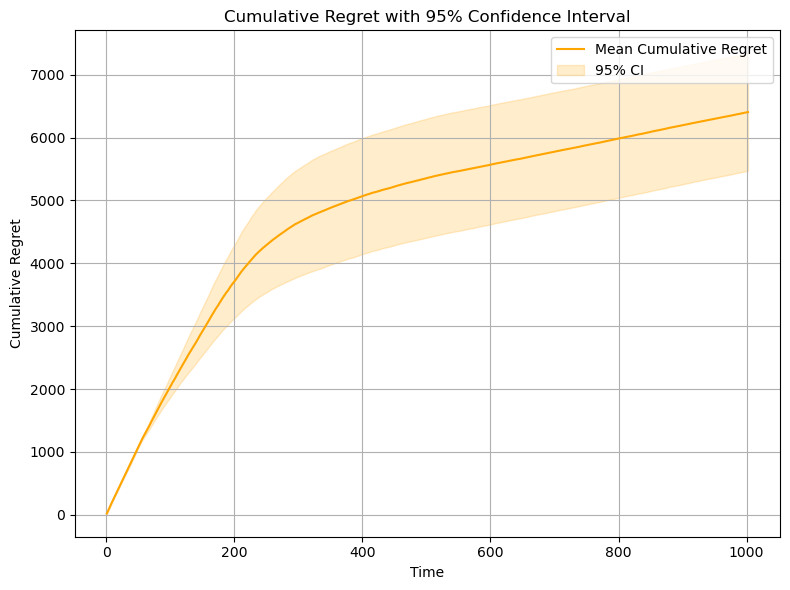

In [11]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [12]:
np.save('cumulative_regret_lasso-stochastic-bandit-d50-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_lasso-stochastic-bandit-d50-s10_10times.npy', l_2_error_parameter_times)

# SA Lasso Bandit

In [5]:
from sklearn.linear_model import Lasso

def SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)
        

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [6]:
def optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [8]:
def while_SA_lasso_bandit_no_variance(beta_star):
    error_std = 1
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [ ]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_SA_lasso_bandit_no_variance(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

parameter square error:15.414143844286865
time 2: mean reward 2.293601803733405
parameter square error:15.441498394285373
time 3: mean reward 5.890814802189557
parameter square error:15.58185492006436
time 4: mean reward 3.4447767158001135
parameter square error:15.500970699025048
time 5: mean reward 1.4225305584909917
parameter square error:15.85740270896294
time 6: mean reward 3.6890789490268516
parameter square error:15.808285315788716
time 7: mean reward 4.898927506922323
parameter square error:15.743552773357417
time 8: mean reward 9.926489635451256
parameter square error:16.37960249209268
time 9: mean reward 1.9459286259293873
parameter square error:15.3165635056175
time 10: mean reward -2.2491715239840593
parameter square error:16.63199751671656
time 11: mean reward 3.7706315738148906
parameter square error:14.392791728857219
time 12: mean reward 13.027891719083236
parameter square error:15.090779501077177
time 13: mean reward 7.691069425523564
parameter square error:13.89830042

In [27]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [   22.23604618    43.05733135    64.23167844 ... 11353.52147474
 11357.31444875 11361.59311744]
Cumulative Regret Std: [   3.73718631    5.81555092    5.56784355 ... 1118.30279215 1118.66650706
 1119.87786308]
L2 Error Parameter Mean: [15.51487802 15.50649433 15.44632076 15.49735465 15.50637193 15.50637193
 15.50637193 15.50637193 15.50638551 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.49792345
 15.49241377 15.49272346 15.48403452 15.4735457  15.46500933 15.45856334
 15.46822118 15.45122337 15.44198707 15.45053994 15.43165776 15.41929302
 15.40829461 15.40911043 15.40249825 15.39239766 15.3804722  15.36638621
 15.37187065 15.34858636 15.33835217 15.33045695 15.32871952 15.31310667
 15.29278821 15.2999757  15.29096813 15.28387547 15.27045108 15.2671865
 15.26710978 15.26181291 15.24983844 15.25758802 15.25787987 15.26696774
 15.2733301

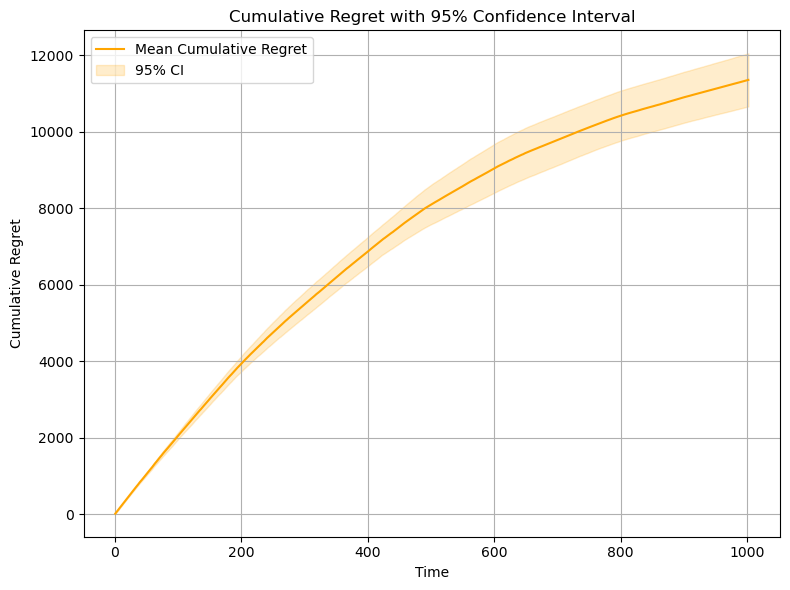

In [28]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [30]:
np.save('cumulative_regret_SA-lasso-bandit-d50-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_SA-lasso-bandit-d50-s10_10times.npy', l_2_error_parameter_times)